### Run this script to select which GPU to use (i.e. 2 or 3 in Tomago for this project)

In [18]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" # Only GPU 2 is visible to this script
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib notebook
from argparse import ArgumentParser
import yaml
import os
import math
import torch
from torch.utils.data import DataLoader

import torch.multiprocessing as mp

from torch.nn.parallel import DistributedDataParallel as DDP
# from torch import vmap
from functorch import vmap, grad
from models import FNN2d, FNN3d
from train_utils import Adam
# from train_utils.datasets import BurgersLoader
# from train_utils.train_2d import train_2d_burger
# from train_utils.eval_2d import eval_burgers

# from solver.WaveEq import WaveEq1D, WaveEq2D
from solver.BurgersEq import BurgersEq1D, BurgersEq2D, BurgersEq2D_Vec
from solver.swe import SWE_Linear
import scipy.io
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import traceback
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from tqdm import tqdm
from train_utils.utils import save_checkpoint, get_grid3d, convert_ic, torch2dgrid, load_checkpoint, load_config, update_config
from train_utils.losses import LpLoss
from train_utils.datasets import DataLoader2D_swe

from solver.my_random_fields import GRF_Mattern
from importlib import reload
import imageio
try:
    import wandb
except ImportError:
    wandb = None


# Define Loss for Fourier Derivatives

In [20]:
def FDM_swe_lin(h, u, v, D=1, f=0.0, g=1.0, H=1.0):
    batchsize = u.size(0)
    nx = u.size(1)
    ny = u.size(2)
    nt = u.size(3)
    h = h.reshape(batchsize, nx, ny, nt)
    u = u.reshape(batchsize, nx, ny, nt)
    v = v.reshape(batchsize, nx, ny, nt)
    dt = D / (nt-1)
    dx = D / (nx)
#     u2 = u**2
    h_h = torch.fft.fftn(h, dim=[1, 2])
    u_h = torch.fft.fftn(u, dim=[1, 2])
    v_h = torch.fft.fftn(v, dim=[1, 2])
#     u2_h = torch.fft.fftn(u2, dim=[1, 2])
    # Wavenumbers in y-direction
    k_max = nx//2
    N = nx
    k_x = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).reshape(N, 1).repeat(1, N).reshape(1,N,N,1)
    k_y = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).reshape(1, N).repeat(N, 1).reshape(1,N,N,1)
    
    hx_h = 2j*np.pi*k_x*h_h
    hy_h = 2j*np.pi*k_y*h_h
    
    
    ux_h = 2j*np.pi*k_x*u_h
#     uxx_h = 2j*np.pi*k_x*ux_h
    uy_h = 2j*np.pi*k_y*u_h
#     uyy_h = 2j*np.pi*k_y*uy_h
    
    vx_h = 2j*np.pi*k_x*v_h
#     vxx_h = 2j*np.pi*k_x*vx_h
    vy_h = 2j*np.pi*k_y*v_h
#     vyy_h =2j *np.pi*k_y*vy_h


    hx = torch.fft.irfftn(hx_h[:, :, :k_max+1], dim=[1, 2])
    hy = torch.fft.irfftn(hy_h[:, :, :k_max+1], dim=[1, 2])
    ht = (h[..., 2:] - h[..., :-2]) / (2 * dt)
    
    ux = torch.fft.irfftn(ux_h[:, :, :k_max+1], dim=[1, 2])
    uy = torch.fft.irfftn(uy_h[:, :, :k_max+1], dim=[1, 2])
#     uxx = torch.fft.irfftn(uxx_h[:, :, :k_max+1], dim=[1, 2])
#     uyy = torch.fft.irfftn(uyy_h[:, :, :k_max+1], dim=[1, 2])
    ut = (u[..., 2:] - u[..., :-2]) / (2 * dt)
    
    vx = torch.fft.irfftn(vx_h[:, :, :k_max+1], dim=[1, 2])
    vy = torch.fft.irfftn(vy_h[:, :, :k_max+1], dim=[1, 2])
#     vxx = torch.fft.irfftn(vxx_h[:, :, :k_max+1], dim=[1, 2])
#     vyy = torch.fft.irfftn(vyy_h[:, :, :k_max+1], dim=[1, 2])
    vt = (v[..., 2:] - v[..., :-2]) / (2 * dt)
#     utt = (u[..., 2:] - 2.0*u[..., 1:-1] + u[..., :-2]) / (dt**2)
#     Du = ut + (0.5*(u2x + u2y) - nu*(uxx + uyy))[..., 1:-1]
    Dh = ht + (H*(ux + vy))[..., 1:-1]
    Du = ut + (g*hx - f*v)[..., 1:-1]
    Dv = vt + (g*hy + f*u)[..., 1:-1]
#     Du = ut + (u*(ux + uy) - nu*(uxx + uyy))[..., 1:-1]
    return Dh, Du, Dv

def swe_loss(s_pred, s_true, use_sum=True):
    h_pred = s_pred[..., 0]
    u_pred = s_pred[..., 1]
    v_pred = s_pred[..., 2]
    h_true = s_true[..., 0]
    u_true = s_true[..., 1]
    v_true = s_true[..., 2]
    lploss = LpLoss(size_average=True)
    loss_h = lploss(h_pred, h_true)
    loss_u = lploss(u_pred, u_true)
    loss_v = lploss(v_pred, v_true)
    loss_s = torch.stack([loss_h, loss_u, loss_v], dim=-1)
    if use_sum:
        data_loss = torch.sum(loss_s)
    else:
        data_loss = torch.mean(loss_s)
    return data_loss
    
    

def PINO_loss_swe_lin(s, s0, f=0.0, g=1.0, H=1.0, h_weight=1.0, u_weight=1.0, v_weight=1.0):
    batchsize = s.size(0)
    nx = s.size(1)
    ny = s.size(2)
    nt = s.size(3)
    s = s.reshape(batchsize, nx, ny, nt, 3)

    lploss = LpLoss(size_average=True)
    s_ic = s[..., 0, 0].reshape(s0.shape)
    loss_ic = lploss(s_ic, s0)
#     index_t = torch.zeros(nx,).long()
#     index_x = torch.tensor(range(nx)).long()
#     boundary_u = u[:, index_t, index_x]
#     loss_u = F.mse_loss(boundary_u, u0)

#     Du = FDM_Burgers(u, nu=nu)[:, :, :, :]
    h = s[..., 0]
    u = s[..., 1]
    v = s[..., 2]
    Dh, Du, Dv = FDM_swe_lin(h, u, v, f=f, g=g, H=H)
    Dh *= h_weight
    Du *= u_weight
    Dv *= v_weight
    Ds = torch.stack([Dh, Du, Dv], dim=-1)
    f_ = torch.zeros(Ds.shape, device=s.device) # use f_ to distinguish from corriolous const f
    loss_f = F.mse_loss(Ds, f_)

    # loss_bc0 = F.mse_loss(u[:, :, 0], u[:, :, -1])
    # loss_bc1 = F.mse_loss((u[:, :, 1] - u[:, :, -1]) /
    #                       (2/(nx)), (u[:, :, 0] - u[:, :, -2])/(2/(nx)))
    return loss_ic, loss_f

# Define Training Fuction

In [21]:
def train_swe_lin(model,
                  dataset,
                  train_loader,
                  optimizer, scheduler,
                  config,
                  f=0.0, g=1.0, H=1.0,
                  rank=0, log=False,
                  project='PINO-2d-default',
                  group='default',
                  tags=['default'],
                  use_tqdm=True):
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method="fork"))

    data_weight = config['train']['xy_loss']
    f_weight = config['train']['f_loss']
    ic_weight = config['train']['ic_loss']
    h_weight = config['train']['h_loss']
    u_weight = config['train']['u_loss']
    v_weight = config['train']['v_loss']
    ckpt_freq = config['train']['ckpt_freq']
    nin = config['data']['nin']
    
    nfields = config['model']['out_dim']
#     nfields = model.out_dim
    model.train()
    myloss = LpLoss(size_average=True)
    S, T = dataset.S, dataset.T
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)

    for e in pbar:
        model.train()
        train_pino = 0.0
        train_ic = 0.0
        data_l2 = 0.0
        train_loss = 0.0
        

        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            out = model(x).reshape(y.shape)
#             data_loss = myloss(out, y)
            swe_loss(out, y)
#             u0 = x[..., 0, -2]
#             v0 = x[..., 0, -1]
#             s0 = x[..., 0, -2:]
            s0 = x[..., 0,  -1]
            loss_ic, loss_f = PINO_loss_swe_lin(out, s0, f=f, g=g, H=H, h_weight=h_weight, u_weight=u_weight, v_weight=v_weight)
            total_loss = loss_ic * ic_weight + loss_f * f_weight + data_loss * data_weight

            optimizer.zero_grad()

            total_loss.backward()
            optimizer.step()
            data_l2 += data_loss.item()
            train_pino += loss_f.item()
            train_ic += loss_ic.item()
            train_loss += total_loss.item()
        scheduler.step()
        data_l2 /= len(train_loader)
        train_pino /= len(train_loader)
        train_ic /= len(train_loader)
        train_loss /= len(train_loader)
        if use_tqdm:
            pbar.set_description(
                (
                    f'Epoch {e}, train loss: {train_loss:.5f} '
                    f'train f error: {train_pino:.5f}; '
                    f'data l2 error: {data_l2:.5f}; '
                    f'train ic error: {train_ic:.5f}'
                )
            )
        if wandb and log:
            wandb.log(
                {
                    'Train f error': train_pino,
                    'Train L2 error': data_l2,
                    'Train ic error': loss_ic,
                    'Train loss': train_loss,
                }
            )

        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_{e}.pt'),
                            model, optimizer)
    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'],
                    model, optimizer)
    print('Done!')

In [22]:
def train_swe_lin_pad(model,
                      dataset,
                      train_loader,
                      optimizer, scheduler,
                      config,
                      f=0.0, g=1.0, H=1.0, 
                      padding=0,
                      rank=0, log=False,
                      project='PINO-2d-default',
                      group='default',
                      tags=['default'],
                      use_tqdm=True):
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method="fork"))

    data_weight = config['train']['xy_loss']
    f_weight = config['train']['f_loss']
    ic_weight = config['train']['ic_loss']
    h_weight = config['train']['h_loss']
    u_weight = config['train']['u_loss']
    v_weight = config['train']['v_loss']
    ckpt_freq = config['train']['ckpt_freq']
    nin = config['data']['nin']
    nfields = config['model']['out_dim']
    
    
#     nfields = model.out_dim
    model.train()
    myloss = LpLoss(size_average=True)
    S, T = dataset.S, dataset.T
    batch_size = config['train']['batchsize']
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)

    for e in pbar:
        model.train()
        train_pino = 0.0
        train_ic = 0.0
        data_l2 = 0.0
        train_loss = 0.0
        

        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            x_in = F.pad(x, (0, 0, 0, padding), "constant", 0)
            out = model(x_in).reshape(batch_size, S, S, T + padding, nfields)
            out = out[..., :-padding, :]
            s0 = x[..., 0,  -1]
            
#             out = model(x).reshape(y.shape)
#             data_loss = myloss(out, y)
            data_loss = swe_loss(out, y)
            
            loss_ic, loss_f = PINO_loss_swe_lin(out, s0, f=f, g=g, H=H, h_weight=h_weight, u_weight=u_weight, v_weight=v_weight)
            total_loss = loss_ic * ic_weight + loss_f * f_weight + data_loss * data_weight

            optimizer.zero_grad()

            total_loss.backward()
            optimizer.step()
            data_l2 += data_loss.item()
            train_pino += loss_f.item()
            train_ic += loss_ic.item()
            train_loss += total_loss.item()
        scheduler.step()
        data_l2 /= len(train_loader)
        train_pino /= len(train_loader)
        train_ic /= len(train_loader)
        train_loss /= len(train_loader)
        if use_tqdm:
            pbar.set_description(
                (
                    f'Epoch {e}, train loss: {train_loss:.5f} '
                    f'train f error: {train_pino:.5f}; '
                    f'data l2 error: {data_l2:.5f}; '
                    f'train ic error: {train_ic:.5f}'
                )
            )
        if wandb and log:
            wandb.log(
                {
                    'Train f error': train_pino,
                    'Train L2 error': data_l2,
                    'Train ic error': loss_ic,
                    'Train loss': train_loss,
                }
            )

        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_{e}.pt'),
                            model, optimizer)
    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'],
                    model, optimizer)
    print('Done!')

# Define Eval Function

In [23]:
def eval_swe_lin(model,
                 dataloader,
                 config,
                 device,
                 f=0.0, g=1.0, H=1.0, 
                 use_tqdm=True):
    model.eval()
    nfields = config['model']['out_dim']
    nin = config['data']['nin']

    h_weight = config['train']['h_loss']
    u_weight = config['train']['u_loss']
    v_weight = config['train']['v_loss']
    myloss = LpLoss(size_average=True)
    if use_tqdm:
        pbar = tqdm(dataloader, dynamic_ncols=True, smoothing=0.05)
    else:
        pbar = dataloader

    test_err = []
    f_err = []
    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x).reshape(y.shape)
#             data_loss = myloss(out, y)
            data_loss = swe_loss(out, y, use_sum=False)
#             s0 = x[..., 0, -nfields:]
            s0 = x[..., 0,  -1]
            loss_ic, loss_f = PINO_loss_swe_lin(out, s0, f=f, g=g, H=H, h_weight=h_weight, u_weight=u_weight, v_weight=v_weight)
            test_err.append(data_loss.item())
            f_err.append(loss_f.item())

    mean_f_err = np.mean(f_err)
    std_f_err = np.std(f_err, ddof=1) / np.sqrt(len(f_err))

    mean_err = np.mean(test_err)
    std_err = np.std(test_err, ddof=1) / np.sqrt(len(test_err))

    print(f'==Averaged relative L2 error mean: {mean_err}, std error: {std_err}==\n'
          f'==Averaged equation error mean: {mean_f_err}, std error: {std_f_err}==')



In [24]:
def eval_swe_lin_pad(model,
                     dataloader,
                     config,
                     device,
                     f=0.0, g=1.0, H=1.0,
                     padding=0,
                     use_tqdm=True):
    model.eval()
    nfields = config['model']['out_dim']
    nin = config['data']['nin']
    h_weight = config['train']['h_loss']
    u_weight = config['train']['u_loss']
    v_weight = config['train']['v_loss']
    myloss = LpLoss(size_average=True)
    if use_tqdm:
        pbar = tqdm(dataloader, dynamic_ncols=True, smoothing=0.05)
    else:
        pbar = dataloader

    test_err = []
    f_err = []
    
    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            batch_size, S, S, T, nfields = y.shape
            x_in = F.pad(x, (0, 0, 0, padding), "constant", 0)
            out = model(x_in).reshape(batch_size, S, S, T + padding, nfields)
#             display(out.shape)
            out = out[..., :-padding, :].reshape(y.shape)
#             display(y.shape)
#             display(out.shape)
            data_loss = swe_loss(out, y, use_sum=False)
#             s0 = x[..., 0, -nfields:]
            s0 = x[..., 0,  -1]
            
            loss_ic, loss_f = PINO_loss_swe_lin(out, s0, f=f, g=g, H=H, h_weight=h_weight, u_weight=u_weight, v_weight=v_weight)
            test_err.append(data_loss.item())
            f_err.append(loss_f.item())

    mean_f_err = np.mean(f_err)
    std_f_err = np.std(f_err, ddof=1) / np.sqrt(len(f_err))

    mean_err = np.mean(test_err)
    std_err = np.std(test_err, ddof=1) / np.sqrt(len(test_err))

    print(f'==Averaged relative L2 error mean: {mean_err}, std error: {std_err}==\n'
          f'==Averaged equation error mean: {mean_f_err}, std error: {std_f_err}==')



# Load Configuration File

In [25]:

config_file = 'configs/custom/swe_linear-0000.yaml'
# config_file = 'configs/custom/swe_linear-0001.yaml'
config = load_config(config_file)
display(config)

{'data': {'name': 'SWE_Linear-0000',
  'total_num': 10,
  'n_train': 5,
  'n_test': 5,
  'nx': 128,
  'nt': 100,
  'sub': 1,
  'sub_t': 1,
  'nin': 1,
  'nout': 3,
  'f': 0.0,
  'g': 0.01,
  'H': 100.0},
 'model': {'layers': [64, 64, 64, 64, 64],
  'modes1': [8, 8, 8, 8],
  'modes2': [8, 8, 8, 8],
  'modes3': [8, 8, 8, 8],
  'fc_dim': 128,
  'in_dim': 4,
  'out_dim': 3,
  'activation': 'gelu',
  'padding': 5},
 'train': {'batchsize': 1,
  'epochs': 150,
  'milestones': [25, 50, 75, 100, 125, 150],
  'base_lr': 0.001,
  'scheduler_gamma': 0.5,
  'ic_loss': 5.0,
  'f_loss': 2.0,
  'xy_loss': 10.0,
  'h_loss': 1.0,
  'u_loss': 100.0,
  'v_loss': 100.0,
  'save_dir': 'SWE_Linear',
  'save_name': 'SWE_Linear-0000.pt',
  'ckpt': 'checkpoints/SWE_Linear/SWE_Linear-0000.pt',
  'ckpt_freq': 25},
 'log': {'project': 'PINO-SWE_Linear', 'group': 'SWE_Linear-0000'},
 'test': {'batchsize': 1, 'ckpt': 'checkpoints/SWE_Linear/SWE_Linear-0000.pt'}}

# Define Parameters

In [26]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dim = 2
N = config['data']['nx']
Nt = config['data']['nt']
Nx = N
Ny = N
l = 0.1
L = 1.0
sigma = 2.0 #2.0
# nu = 0.01
f = config['data']['f']
g = config['data']['g']
havg = config['data']['H']
Nu = None
Nsamples = config['data']['total_num']  #config['data']['total_num'] if f != 0 else config['data']['total_num'] - 1
dt = 1.0e-3
tend = 1
save_int = int(tend/dt/Nt)
# save_int = 10 #int(1e-2*tend/dt)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [27]:
f==0

True

# Generate Random Fields

In [28]:
grf = GRF_Mattern(dim, N, length=L, nu=Nu, l=l, sigma=sigma, boundary="periodic", device=device)
H0 = grf.sample(Nsamples)
# V0 = grf.sample(Nsamples)

# Plot Random Fields

In [29]:
key = 1
x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
h0 = H0[key].cpu().numpy()
# v0 = V0[key].cpu().numpy()
# u0, v0
h0

array([[-0.18070942, -0.1919322 , -0.20717356, ..., -0.17810772,
        -0.17335618, -0.17432353],
       [-0.17370166, -0.18745214, -0.2055952 , ..., -0.16640553,
        -0.1626844 , -0.1652319 ],
       [-0.16732305, -0.18313667, -0.20369388, ..., -0.1564971 ,
        -0.15346465, -0.15720147],
       ...,
       [-0.20829988, -0.20980537, -0.21398634, ..., -0.22446576,
        -0.2153804 , -0.2100366 ],
       [-0.19765607, -0.20266952, -0.21085107, ..., -0.20707515,
        -0.19954222, -0.19646662],
       [-0.18858533, -0.19687009, -0.20876807, ..., -0.19164349,
        -0.1855908 , -0.1846542 ]], dtype=float32)

In [30]:
# fig = plt.figure()
# ax = fig.add_subplot(111)

# # fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# # surf = ax.plot_surface(X, Y, u0, cmap='jet', linewidth=0, antialiased=True, vmin=-2, vmax=2)
# c = plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')

# # fig.colorbar(surf, shrink=0.5, aspect=5)
# fig.colorbar(c)

# plt.title('GRF 2D')
# plt.axis('square')
# plt.show()

fig = plt.figure(figsize=(6,5))
plt.subplot(1,1,1)
plt.pcolormesh(X, Y, h0, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Intial Condition $h(x,y)$')
plt.tight_layout()
plt.axis('square')

# plt.subplot(1,2,2)
# plt.pcolormesh(X, Y, v0, cmap='jet', shading='gouraud')
# plt.colorbar()
# plt.xlabel('$x$')
# plt.ylabel('$y$')
# plt.title('Intial Condition $v(x,y)$')
# plt.tight_layout()
# plt.axis('square')
# plt.show()

<IPython.core.display.Javascript object>

(np.float64(0.0),
 np.float64(0.9921875),
 np.float64(0.0),
 np.float64(0.9921875))

In [31]:
H0.shape

torch.Size([10, 128, 128])

In [32]:
fig, ax1 = plt.subplots(figsize=(6,5), subplot_kw={"projection": "3d"})
surf1 = ax1.plot_surface(X, Y, h0, cmap='jet', linewidth=0, antialiased=True,)
# plt.colorbar(surf1, shrink=0.5, aspect=5)
plt.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
ax1.set_title('u0')
# surf2 = ax2.plot_surface(X, Y, v0, cmap='jet', linewidth=0, antialiased=True,)
# plt.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
# ax2.set_title('v0')
plt.tight_layout()


plt.show()



<IPython.core.display.Javascript object>

# Evolve the SWE

## Gaussian Test

In [33]:
swe_test = SWE_Linear(Nx=Nx, Ny=Ny, f=f, havg=havg, g=g, dt=dt, tend=tend, device=device)
h0_test = swe_test.initialize_gaussian(amp=1.0)
htest, utest, vtest = swe_test.driver(h0_test)
htest = htest.cpu().float()
utest = utest.cpu().float()
vtest = vtest.cpu().float()

In [34]:
# %matplotlib notebook
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24,5))

plt.ion()
ax4.axis('off')


fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
# pcm1 = ax1.plot_pcmace(X, Y, true[..., 0], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm1 = ax1.pcolormesh(X, Y, htest[0], cmap='jet', label='h', shading='auto')

pcm2 = ax2.pcolormesh(X, Y, utest[-1], cmap='jet', label='u', shading='auto')

# plt.colorbar()
# pcm2 = ax2.plot_pcmace(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm3 = ax3.pcolormesh(X, Y, vtest[-1], cmap='jet', label='v', shading='auto')

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='auto')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(pcm, shrink=0.5, aspect=5)

# ax.
# ax.set_clim(-1, 1)
# display(ax.get_clim())
clim1 = pcm1.get_clim()
pcm1.set_clim(clim1)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')

clim2 = pcm2.get_clim()
pcm2.set_clim(clim2)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')

clim3 = pcm2.get_clim()
pcm3.set_clim(clim3)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$y$')

ax1.set_title(f'h')
ax2.set_title(f'u')
ax3.set_title(f'v')

# plt.axis('square')

plt.colorbar(pcm1, ax=ax1)
plt.colorbar(pcm2, ax=ax2)
plt.colorbar(pcm3, ax=ax3)
ax1.axis('square')
ax2.axis('square')
ax3.axis('square')
plt.tight_layout()
# ax3.axis('off')
# ax2.tight_layout()

# movie_dir = "Burgers2D_movie"
# movie_filename = "Burgers2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(htest)):
    ax1.clear()
    ax2.clear()
    ax3.clear()
    pcm1 = ax1.pcolormesh(X, Y, htest[i], cmap='jet', label='h', shading='auto')
    pcm2 = ax2.pcolormesh(X, Y, utest[i], cmap='jet', label='u', shading='auto')

    pcm3 = ax3.pcolormesh(X, Y, vtest[i], cmap='jet', label='v', shading='auto')
#     plt.axis('square')

    pcm1.set_clim(clim1)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    pcm2.set_clim(clim2)
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    pcm3.set_clim(clim3)
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$y$')
    
    ax1.set_title(f'h')
    ax2.set_title(f'u')
    ax3.set_title(f'v')
#     plt.title(f'Burgers Equation')
    ax1.axis('square')
    ax2.axis('square')
    ax3.axis('square')    
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)


<IPython.core.display.Javascript object>

In [35]:
# %matplotlib notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), subplot_kw={"projection": "3d"})

plt.ion()

ax2.axis('off')

fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')

surf1 = ax1.plot_surface(X, Y, htest[0].numpy(), cmap='jet', label='h', linewidth=0.0, antialiased=False)

# plt.colorbar()
# surf2 = ax2.plot_surface(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
# surf2 = ax2.plot_surface(X, Y, v[0].numpy(), cmap='jet', label='v',linewidth=0.0, antialiased=False)

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax1.get_zlim()
ax1.set_zlim(zlim)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
# ax2.set_zlim(zlim)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$y$')
ax1.set_title(f'h')
# ax2.set_title(f'v')
# plt.axis('square')

plt.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
# plt.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
plt.tight_layout()

# ax2.tight_layout()

# movie_dir = "Burgers2D_movie"
# movie_filename = "Burgers2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(htest)):
    ax1.clear()
#     ax2.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
#     surf1 = ax1.plot_surface(X, Y, true[..., i], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
    surf1 = ax1.plot_surface(X, Y, htest[i].numpy(), cmap='jet', label='h', linewidth=0.0, antialiased=False)
#     surf2 = ax2.plot_surface(X, Y, pred[..., i], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
#     surf2 = ax2.plot_surface(X, Y, v[i].numpy(), cmap='jet', label='pred',linewidth=0.0, antialiased=False)

    ax1.set_zlim(zlim)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
#     ax2.set_zlim(zlim)
#     ax2.set_xlabel('$x$')
    
#     ax2.set_ylabel('$y$')
    ax1.set_title(f'h')
#     ax2.set_title(f'v')
#     plt.title(f'Burgers Equation')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



<IPython.core.display.Javascript object>

## Random Initial Data

In [36]:
swe_eq = SWE_Linear(Nx=Nx, Ny=Ny, f=f, g=g, havg=havg, dt=dt, tend=tend, device=device)
H, U, V = vmap(swe_eq.driver, in_dims=(0, None))(H0, save_int)

/tmp/ipykernel_1549396/204720191.py:2: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  H, U, V = vmap(swe_eq.driver, in_dims=(0, None))(H0, save_int)


In [37]:
H = H.cpu()
U = U.cpu()
V = V.cpu()
X = swe_eq.X.cpu()
Y = swe_eq.Y.cpu()
torch.cuda.empty_cache()

In [38]:
ah = H0.cpu().float()
h = H.cpu().float()

u = U.cpu().float()
# av = V0.cpu().float()
v = V.cpu().float()
display(h.shape)
display(ah.shape)
display(u.shape)
display(v.shape)

torch.Size([10, 101, 128, 128])

torch.Size([10, 128, 128])

torch.Size([10, 101, 128, 128])

torch.Size([10, 101, 128, 128])

# Plot Data

In [39]:
# %matplotlib notebook
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24,5))

plt.ion()
ax4.axis('off')


fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
# pcm1 = ax1.plot_pcmace(X, Y, true[..., 0], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm1 = ax1.pcolormesh(X, Y, h[key, 0], cmap='jet', label='h', shading='auto')

pcm2 = ax2.pcolormesh(X, Y, u[key, -1], cmap='jet', label='u', shading='auto')

# plt.colorbar()
# pcm2 = ax2.plot_pcmace(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm3 = ax3.pcolormesh(X, Y, v[key, -1], cmap='jet', label='v', shading='auto')

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='auto')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(pcm, shrink=0.5, aspect=5)

# ax.
# ax.set_clim(-1, 1)
# display(ax.get_clim())
clim1 = pcm1.get_clim()
pcm1.set_clim(clim1)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')

clim2 = pcm2.get_clim()
pcm2.set_clim(clim2)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')

clim3 = pcm2.get_clim()
pcm3.set_clim(clim3)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$y$')

ax1.set_title(f'h')
ax2.set_title(f'u')
ax3.set_title(f'v')

# plt.axis('square')

plt.colorbar(pcm1, ax=ax1)
plt.colorbar(pcm2, ax=ax2)
plt.colorbar(pcm3, ax=ax3)
ax1.axis('square')
ax2.axis('square')
ax3.axis('square')
plt.tight_layout()
# ax3.axis('off')
# ax2.tight_layout()

# movie_dir = "Burgers2D_movie"
# movie_filename = "Burgers2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(h[key])):
    ax1.clear()
    ax2.clear()
    ax3.clear()
    pcm1 = ax1.pcolormesh(X, Y, h[key, i], cmap='jet', label='h', shading='auto')
    pcm2 = ax2.pcolormesh(X, Y, u[key, i], cmap='jet', label='u', shading='auto')

    pcm3 = ax3.pcolormesh(X, Y, v[key, i], cmap='jet', label='v', shading='auto')
#     plt.axis('square')

    pcm1.set_clim(clim1)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    pcm2.set_clim(clim2)
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    pcm3.set_clim(clim3)
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$y$')
    
    ax1.set_title(f'h')
    ax2.set_title(f'u')
    ax3.set_title(f'v')
#     plt.title(f'Burgers Equation')
    ax1.axis('square')
    ax2.axis('square')
    ax3.axis('square')    
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



<IPython.core.display.Javascript object>

In [40]:
# %matplotlib notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), subplot_kw={"projection": "3d"})

plt.ion()

ax2.axis('off')

fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')

surf1 = ax1.plot_surface(X, Y, H[key, 0].numpy(), cmap='jet', label='h', linewidth=0.0, antialiased=False)

# plt.colorbar()
# surf2 = ax2.plot_surface(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
# surf2 = ax2.plot_surface(X, Y, v[key, 0].numpy(), cmap='jet', label='v',linewidth=0.0, antialiased=False)

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax1.get_zlim()
ax1.set_zlim(zlim)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
# ax2.set_zlim(zlim)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$y$')
ax1.set_title(f'h')
# ax2.set_title(f'v')
# plt.axis('square')

plt.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
# plt.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
plt.tight_layout()

# ax2.tight_layout()

# movie_dir = "Burgers2D_movie"
# movie_filename = "Burgers2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(h[key])):
    ax1.clear()
#     ax2.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
#     surf1 = ax1.plot_surface(X, Y, true[..., i], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
    surf1 = ax1.plot_surface(X, Y, h[key, i].numpy(), cmap='jet', label='h', linewidth=0.0, antialiased=False)
#     surf2 = ax2.plot_surface(X, Y, pred[..., i], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
#     surf2 = ax2.plot_surface(X, Y, v[key, i].numpy(), cmap='jet', label='pred',linewidth=0.0, antialiased=False)

    ax1.set_zlim(zlim)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
#     ax2.set_zlim(zlim)
#     ax2.set_xlabel('$x$')
    
#     ax2.set_ylabel('$y$')
    ax1.set_title(f'h')
#     ax2.set_title(f'v')
#     plt.title(f'Burgers Equation')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



<IPython.core.display.Javascript object>

# Define the DataLoaders

In [41]:
# use_gaussian_test = True if f == 0 else False
use_gaussian_test = False
data = torch.stack([h,u,v], dim=-1)
if use_gaussian_test:
    data_test = torch.stack([htest, utest, vtest], dim=-1)[None] # custom gaussian
    data = torch.cat([data, data_test], dim=0)
dataset = DataLoader2D_swe(data, config['data']['nx'], config['data']['nt'], config['data']['sub'], config['data']['sub_t'])
train_loader = dataset.make_loader(config['data']['n_train'], config['train']['batchsize'], start=0, train=True)
test_loader = dataset.make_loader(config['data']['n_test'], config['test']['batchsize'], start=config['data']['n_train'], train=False)

# Define the Model

In [42]:
log = False
# config = config_train
model = FNN3d(modes1=config['model']['modes1'],
              modes2=config['model']['modes2'],
              modes3=config['model']['modes3'],
              fc_dim=config['model']['fc_dim'],
              layers=config['model']['layers'], 
              in_dim=config['model']['in_dim'],
              out_dim=config['model']['out_dim'],
              activation=config['model']['activation'],
             ).to(device)

In [43]:
optimizer = Adam(model.parameters(), betas=(0.9, 0.999), lr=config['train']['base_lr'])

In [44]:
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,
                                                 milestones=config['train']['milestones'],
                                                 gamma=config['train']['scheduler_gamma'])

# Load from checkpoint

In [45]:
load_checkpoint(model, ckpt_path=config['train']['ckpt'], optimizer=None)
# load_checkpoint(model, ckpt_path=config['train']['ckpt'], optimizer=optimizer)

Weights loaded from checkpoints/SWE_Linear/SWE_Linear-0000.pt


# Train the Model

In [46]:
train_swe_lin_pad(model,
                  dataset,
                  train_loader,
                  optimizer, 
                  scheduler,
                  config,
                  f=config['data']['f'], g=config['data']['g'], H=config['data']['H'],
                  padding=5,
                  rank=0,
                  log=log,
                  project=config['log']['project'],
                  group=config['log']['group'])

Epoch 0, train loss: 82.35618 train f error: 7.90752; data l2 error: 6.57777; train ic error: 0.15269:   1%|          | 1/150 [00:04<12:19,  4.96s/it]

Checkpoint is saved at checkpoints/SWE_Linear/SWE_Linear-0000_0.pt


Epoch 25, train loss: 11.58163 train f error: 0.52070; data l2 error: 1.03112; train ic error: 0.04581:  17%|█▋        | 26/150 [01:16<06:15,  3.03s/it]

Checkpoint is saved at checkpoints/SWE_Linear/SWE_Linear-0000_25.pt


Epoch 50, train loss: 4.71160 train f error: 0.11220; data l2 error: 0.43652; train ic error: 0.02440:  34%|███▍      | 51/150 [02:28<04:58,  3.01s/it] 

...

Checkpoint is saved at checkpoints/SWE_Linear/SWE_Linear-0000_100.pt


Epoch 125, train loss: 0.72190 train f error: 0.06260; data l2 error: 0.05762; train ic error: 0.00410:  84%|████████▍ | 126/150 [06:04<01:12,  3.00s/it]

Checkpoint is saved at checkpoints/SWE_Linear/SWE_Linear-0000_125.pt


Epoch 149, train loss: 0.67313 train f error: 0.06161; data l2 error: 0.05371; train ic error: 0.00256: 100%|██████████| 150/150 [07:12<00:00,  2.88s/it]


Checkpoint is saved at checkpoints/SWE_Linear/SWE_Linear-0000.pt
Done!


# Evaluate Model

In [47]:
eval_swe_lin(model,
             test_loader,
             config,
             device,
             f=config['data']['f'], g=config['data']['g'], H=config['data']['H'],
             use_tqdm=True)


100%|██████████| 5/5 [00:01<00:00,  4.51it/s]

==Averaged relative L2 error mean: 0.8100111842155456, std error: 0.014174080528884832==
==Averaged equation error mean: 0.29327904880046846, std error: 0.038983549226234974==


In [48]:
eval_swe_lin_pad(model,
                 test_loader,
                 config,
                 device,
                 f=config['data']['f'], g=config['data']['g'], H=config['data']['H'],
                 padding=5,
                 use_tqdm=True)

100%|██████████| 5/5 [00:00<00:00,  5.14it/s]

==Averaged relative L2 error mean: 0.02743360325694084, std error: 0.000615862307960953==
==Averaged equation error mean: 0.07328366711735726, std error: 0.010751626144081861==


# Generate Test Predictions

In [49]:
use_train_data = False
# padding = 5
batch_size = config['test']['batchsize']
Nx = config['data']['nx']
Ny = config['data']['nx']
Nt = config['data']['nt'] + 1
Ntest = config['data']['n_test']
Ntrain = config['data']['n_train']
loader = test_loader
if use_train_data:
    Ntest = Ntrain
    loader = train_loader

in_dim = config['model']['in_dim']
out_dim = config['model']['out_dim']
model.eval()
# model.to('cpu')
test_x = np.zeros((Ntest,Nx,Ny,Nt,in_dim))
preds_y = np.zeros((Ntest,Nx,Ny,Nt,out_dim))
test_y0 = np.zeros((Ntest,Nx,Ny,out_dim))
test_y = np.zeros((Ntest,Nx,Ny,Nt,out_dim))
with torch.no_grad():
    for i, data in enumerate(test_loader):
        data_x, data_y = data
        data_x, data_y = data_x.to(device), data_y.to(device)
        pred_y = model(data_x).reshape(data_y.shape)
        test_x[i] = data_x.cpu().numpy()
        test_y[i] = data_y.cpu().numpy()
        test_y0[i] = data_x[..., 0, :-out_dim].cpu().numpy() # same way as in training code
        preds_y[i] = pred_y.cpu().numpy()
#     data_loss = myloss(out, y)

## Padding

In [50]:
use_train_data = False
padding = 5
batch_size = config['test']['batchsize']
Nx = config['data']['nx']
Ny = config['data']['nx']
Nt = config['data']['nt'] + 1
Ntest = config['data']['n_test']
Ntrain = config['data']['n_train']
loader = test_loader
if use_train_data:
    Ntest = Ntrain
    loader = train_loader
in_dim = config['model']['in_dim']
out_dim = config['model']['out_dim']

model.eval()
# model.to('cpu')
test_x = np.zeros((Ntest,Nx,Ny,Nt,in_dim))
preds_y = np.zeros((Ntest,Nx,Ny,Nt,out_dim))
test_y0 = np.zeros((Ntest,Nx,Ny,out_dim))
test_y = np.zeros((Ntest,Nx,Ny,Nt,out_dim))

with torch.no_grad():
    for i, data in enumerate(loader):
#     for i, data in enumerate(train_loader):
        data_x, data_y = data
        data_x, data_y = data_x.to(device), data_y.to(device)
#         data_x_pad = F.pad()
#         display(data_x.shape)
        data_x_pad = F.pad(data_x, (0, 0, 0, padding), "constant", 0)
        pred_y_pad = model(data_x_pad).reshape(batch_size, Nx, Ny, Nt + padding, out_dim)
        pred_y = pred_y_pad[..., :-padding, :].reshape(data_y.shape)
#         pred_y = model(data_x).reshape(data_y.shape)
        test_x[i] = data_x.cpu().numpy()
        test_y[i] = data_y.cpu().numpy()
        test_y0[i] = data_x[..., 0, -out_dim:].cpu().numpy() # same way as in training code
        preds_y[i] = pred_y.cpu().numpy()
#     data_loss = myloss(out, y)

# Plot Results

In [51]:
key = 0
# key_t = (Nt - 3)
key_t = (Nt - 1) // 1
pred = preds_y[key]
true = test_y[key]


a = test_x[key]
# Nt, Nx, _ = a.shape
h0 = a[..., 0, -1]
# v0 = a[..., 0, -1]
pred_h = pred[..., key_t, 0]
pred_u = pred[..., key_t, 1]
pred_v = pred[..., key_t, 2]
true_h = true[..., key_t, 0]
true_u = true[..., key_t, 1]
true_v = true[..., key_t, 2]

# T = a[:,:,2]
# X = a[:,:,1]
# x = X[0]
x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
u0 = torch.zeros_like(X)
v0 = torch.zeros_like(X)
t = a[0, 0, key_t, 2]
grid_x, grid_y, grid_t = get_grid3d(Nx, Nt)
# X = X.reshape(Nx, Nx)

In [52]:
fig = plt.figure(figsize=(24,15))
plt.subplot(3,4,1)

plt.pcolormesh(X, Y, h0, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Intial Condition $h(x,y)$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,2)
# plt.pcolor(XX,TT, S_test, cmap='jet')
plt.pcolormesh(X, Y, true_h, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Exact $h(x,y,t={t:.2f})$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,3)
# plt.pcolor(XX,TT, S_pred, cmap='jet')
plt.pcolormesh(X, Y, pred_h, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Predict $h(x,y,t={t:.2f})$')
plt.axis('square')

plt.tight_layout()

plt.subplot(3,4,4)
# plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
plt.pcolormesh(X, Y, pred_h - true_h, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Absolute error h')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,5)
plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Intial Condition $u(x,y)$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,6)
# plt.pcolor(XX,TT, S_test, cmap='jet')
plt.pcolormesh(X, Y, true_u, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Exact $u(x,y,t={t:.2f})$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,7)
# plt.pcolor(XX,TT, S_pred, cmap='jet')
plt.pcolormesh(X, Y, pred_u, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Predict $u(x,y,t={t:.2f})$')
plt.axis('square')

plt.tight_layout()

plt.subplot(3,4,8)
# plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
plt.pcolormesh(X, Y, pred_u - true_u, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Absolute error u')
plt.tight_layout()
plt.axis('square')



plt.subplot(3,4,9)
plt.pcolormesh(X, Y, v0, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Intial Condition $v(x,y)$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,10)
# plt.pcolor(XX,TT, S_test, cmap='jet')
plt.pcolormesh(X, Y, true_v, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Exact $v(x,y,t={t:.2f})$')
plt.tight_layout()
plt.axis('square')

plt.subplot(3,4,11)
# plt.pcolor(XX,TT, S_pred, cmap='jet')
plt.pcolormesh(X, Y, pred_v, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Predict $v(x,y,t={t:.2f})$')
plt.axis('square')

plt.tight_layout()

plt.subplot(3,4,12)
# plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
plt.pcolormesh(X, Y, pred_v - true_v, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Absolute error v')
plt.tight_layout()
plt.axis('square')

<IPython.core.display.Javascript object>

(np.float64(0.0),
 np.float64(0.9921875),
 np.float64(0.0),
 np.float64(0.9921875))

In [53]:
# %matplotlib notebook
fig, axs = plt.subplots(3, 4, figsize=(24,15))

ax1 = axs[0,0]
ax2 = axs[0,1]
ax3 = axs[0,2]
ax4 = axs[1,0]
ax5 = axs[1,1]
ax6 = axs[1,2]

plt.ion()

axs[0,3].axis('off')
axs[1,3].axis('off')
axs[2,0].axis('off')
axs[2,1].axis('off')
axs[2,2].axis('off')
axs[2,3].axis('off')

# fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
pcm1 = ax1.pcolormesh(X, Y, pred[..., -1, 0], cmap='jet', label='pred h', shading='auto')
pcm2 = ax2.pcolormesh(X, Y, pred[..., -1, 1], cmap='jet', label='pred u', shading='auto')
pcm3 = ax3.pcolormesh(X, Y, pred[..., -1, 2], cmap='jet', label='pred v', shading='auto')
pcm4 = ax4.pcolormesh(X, Y, true[..., -1, 0], cmap='jet', label='true h', shading='auto')
pcm5 = ax5.pcolormesh(X, Y, true[..., -1, 1], cmap='jet', label='true u', shading='auto')
pcm6 = ax6.pcolormesh(X, Y, true[..., -1, 2], cmap='jet', label='true v', shading='auto')

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.4, vmax=0.4, cmap='jet', shading='auto')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="4%", pad=0.04)


# fig.colorbar(pcm, shrink=0.4, aspect=4)

# ax.
# ax.set_clim(-1, 1)
# display(ax.get_clim())
clim1 = pcm1.get_clim()
pcm1.set_clim(clim1)
pcm4.set_clim(clim1)


clim2 = pcm2.get_clim()
pcm2.set_clim(clim2)
pcm5.set_clim(clim2)

clim3 = pcm3.get_clim()
pcm3.set_clim(clim3)
pcm6.set_clim(clim3)

ax1.set_title(f'Pred h')
ax2.set_title(f'Pred u')
ax3.set_title(f'Pred v')
ax4.set_title(f'True h')
ax5.set_title(f'True u')
ax6.set_title(f'True v')


# plt.axis('square')

plt.colorbar(pcm1, ax=ax1)
plt.colorbar(pcm2, ax=ax2)
plt.colorbar(pcm3, ax=ax3)
plt.colorbar(pcm4, ax=ax4)
plt.colorbar(pcm5, ax=ax6)
plt.colorbar(pcm6, ax=ax5)

ax1.axis('square')
ax2.axis('square')
ax3.axis('square')
ax4.axis('square')
ax5.axis('square')
ax6.axis('square')
plt.tight_layout()
# ax2.tight_layout()

# movie_dir = "Burgers2D_movie"
# movie_filename = "Burgers2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(true.shape[-2]):
    ax1.clear()
    ax2.clear()
    ax3.clear()
    ax4.clear()
    ax5.clear()
    ax6.clear()
    pcm1 = ax1.pcolormesh(X, Y, pred[..., i, 0], cmap='jet', label='pred h', shading='auto')
    pcm2 = ax2.pcolormesh(X, Y, pred[..., i, 1], cmap='jet', label='pred u', shading='auto')
    pcm3 = ax3.pcolormesh(X, Y, pred[..., i, 2], cmap='jet', label='pred v', shading='auto')
    pcm4 = ax4.pcolormesh(X, Y, true[..., i, 0], cmap='jet', label='true h', shading='auto')
    pcm5 = ax5.pcolormesh(X, Y, true[..., i, 1], cmap='jet', label='true u', shading='auto')
    pcm6 = ax6.pcolormesh(X, Y, true[..., i, 2], cmap='jet', label='true v', shading='auto')

    pcm1.set_clim(clim1)
    pcm4.set_clim(clim1)
    pcm2.set_clim(clim2)
    pcm5.set_clim(clim2)
    pcm3.set_clim(clim3)
    pcm6.set_clim(clim3)
    ax1.set_title(f'Pred h')
    ax2.set_title(f'Pred u')
    ax3.set_title(f'Pred v')
    ax4.set_title(f'True h')
    ax5.set_title(f'True u')
    ax6.set_title(f'True v')
    ax1.axis('square')
    ax2.axis('square')
    ax3.axis('square')
    ax4.axis('square')
    ax5.axis('square')
    ax6.axis('square')
    
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



<IPython.core.display.Javascript object>

# Save and Load Data

In [54]:
def save_data(data_path, test_x, test_y, preds_y, key_t):
    data_dir, data_filename = os.path.split(data_path)
    os.makedirs(data_dir, exist_ok=True)
    np.savez(data_path, test_x=test_x, test_y=test_y, preds_y=preds_y, key_t=key_t)

def load_data(data_path):
    data = np.load(data_path)
    test_x = data['test_x']
    test_y = data['test_y']
    preds_y = data['preds_y']
    key_t = int(data['key_t'])
    return test_x, test_y, preds_y, key_t

In [55]:
data_dir = 'data/SWE_Linear'
data_filename = f"data_f{int(config['data']['f'])}.npz"
data_path = os.path.join(data_dir, data_filename)
# os.makedirs(data_dir, exist_ok=True)
display(data_path)

'data/SWE_Linear/data_f0.npz'

In [56]:
save_data(data_path, test_x, test_y, preds_y, key_t)

In [57]:
def plot_predictions(key, key_t, test_x, test_y, preds_y, print_index=False, save_path=None, font_size=None):
    
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})

    Nsamples, Nx, Ny, Nt, Nfields = preds_y.shape
    
    a = test_x[key]
    # Nt, Nx, _ = a.shape
    h0 = a[..., 0, -1]
    # v0 = a[..., 0, -1]
    pred_h = preds_y[key, ..., key_t, 0]
    pred_u = preds_y[key, ..., key_t, 1]
    pred_v = preds_y[key, ..., key_t, 2]
    true_h = test_y[key, ..., key_t, 0]
    true_u = test_y[key, ..., key_t, 1]
    true_v = test_y[key, ..., key_t, 2]

    # T = a[:,:,2]
    # X = a[:,:,1]
    # x = X[0]
    x = torch.linspace(0, 1, Nx + 1)[:-1]
    y = torch.linspace(0, 1, Ny + 1)[:-1]
    X, Y = torch.meshgrid(x, y, indexing='ij')
    u0 = torch.zeros_like(X)
    v0 = torch.zeros_like(X)
    t = a[0, 0, key_t, 2]
    grid_x, grid_y, grid_t = get_grid3d(Nx, Nt)

    fig = plt.figure(figsize=(24,15))
    plt.subplot(3,4,1)

    plt.pcolormesh(X, Y, h0, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Intial Condition $h(x,y)$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,2)
    # plt.pcolor(XX,TT, S_test, cmap='jet')
    plt.pcolormesh(X, Y, true_h, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Exact $h(x,y,t={t:.2f})$')
    plt.title(f'Exact $h(x,y,t={int(t)})$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,3)
    # plt.pcolor(XX,TT, S_pred, cmap='jet')
    plt.pcolormesh(X, Y, pred_h, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Predict $h(x,y,t={t:.2f})$')
    plt.title(f'Predict $h(x,y,t={int(t)})$')
    plt.axis('square')

    plt.tight_layout()

    plt.subplot(3,4,4)
    # plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
    plt.pcolormesh(X, Y, pred_h - true_h, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Absolute Error h')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,5)
    plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Intial Condition $u(x,y)$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,6)
    # plt.pcolor(XX,TT, S_test, cmap='jet')
    plt.pcolormesh(X, Y, true_u, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Exact $u(x,y,t={t:.2f})$')
    plt.title(f'Exact $u(x,y,t={int(t)})$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,7)
    # plt.pcolor(XX,TT, S_pred, cmap='jet')
    plt.pcolormesh(X, Y, pred_u, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Predict $u(x,y,t={t:.2f})$')
    plt.title(f'Predict $u(x,y,t={int(t)})$')
    plt.axis('square')

    plt.tight_layout()

    plt.subplot(3,4,8)
    # plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
    plt.pcolormesh(X, Y, pred_u - true_u, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Absolute Error u')
    plt.tight_layout()
    plt.axis('square')



    plt.subplot(3,4,9)
    plt.pcolormesh(X, Y, v0, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Intial Condition $v(x,y)$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,10)
    # plt.pcolor(XX,TT, S_test, cmap='jet')
    plt.pcolormesh(X, Y, true_v, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Exact $v(x,y,t={t:.2f})$')
    plt.title(f'Exact $v(x,y,t={int(t)})$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(3,4,11)
    # plt.pcolor(XX,TT, S_pred, cmap='jet')
    plt.pcolormesh(X, Y, pred_v, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Predict $v(x,y,t={t:.2f})$')
    plt.title(f'Predict $v(x,y,t={int(t)})$')
    plt.axis('square')

    plt.tight_layout()

    plt.subplot(3,4,12)
    # plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
    plt.pcolormesh(X, Y, pred_v - true_v, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Absolute Error v')
    plt.tight_layout()
    plt.axis('square')

    
    if save_path is not None:
        plt.savefig(f'{save_path}.png', bbox_inches='tight')
    # plt.show()

    


In [58]:
# f = 0
data_dir = 'data/SWE_Linear'
data_filename = f"data_f{int(f)}.npz"
data_path = os.path.join(data_dir, data_filename)
test_x, test_y, preds_y, key_t = load_data(data_path)

In [59]:
figures_dir = f"SWE_Linear/figures/"
os.makedirs(figures_dir, exist_ok=True)
font_size = 12
for key in range(len(preds_y)):
    save_path = os.path.join(figures_dir, f"SWE_Linear_f{int(f)}_{key}")
    plot_predictions(key, key_t, test_x, test_y, preds_y, print_index=True, save_path=save_path, font_size=font_size)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Movies

In [60]:
def generate_movie_2D(key, test_x, test_y, preds_y, plot_title='', field=0, val_cbar_index=-1, err_cbar_index=-1, val_clim=None, err_clim=None, font_size=None, movie_dir='', movie_name='movie.gif', frame_basename='movie', frame_ext='jpg', remove_frames=True):
    frame_files = []
    
    if movie_dir:
        os.makedirs(movie_dir, exist_ok=True)
    
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})
    
    if len(preds_y.shape) == 4:
        Nsamples, Nx, Ny, Nt = preds_y.shape
        preds_y = preds_y.reshape(Nsamples,Nx,Ny,Nt,1)
        test_y = test_y.reshape(Nsamples,Nx,Ny,Nt,1)
    Nsamples, Nx, Ny, Nt, Nfields = preds_y.shape    
    
    pred = preds_y[key, ..., field]
    true = test_y[key, ..., field]
    error = pred - true
    

    a = test_x[key]
    x = torch.linspace(0, 1, Nx + 1)[:-1]
    y = torch.linspace(0, 1, Ny + 1)[:-1]
    X, Y = torch.meshgrid(x, y, indexing='ij')
    t = a[0, 0, :, 2]
    
    
    fig, axs = plt.subplots(1, 3, figsize=(18,5))
    ax1 = axs[0]
    ax2 = axs[1]
    ax3 = axs[2]
    
    pcm1 = ax1.pcolormesh(X, Y, true[..., val_cbar_index], cmap='jet', label='true', shading='gouraud')
    pcm2 = ax2.pcolormesh(X, Y, pred[..., val_cbar_index], cmap='jet', label='pred', shading='gouraud')
    pcm3 = ax3.pcolormesh(X, Y, error[..., err_cbar_index], cmap='jet', label='error', shading='gouraud')
    
    if val_clim is None:
        val_clim = pcm1.get_clim()
    if err_clim is None:
        err_clim = pcm3.get_clim()
        
    
    
    pcm1.set_clim(val_clim)
    plt.colorbar(pcm1, ax=ax1)
    ax1.axis('square')
    
    
    pcm2.set_clim(val_clim)
    plt.colorbar(pcm2, ax=ax2)
    ax2.axis('square')
    
    pcm3.set_clim(err_clim)
    plt.colorbar(pcm3, ax=ax3)
    ax3.axis('square')

    plt.tight_layout()
    
    for i in range(Nt):
        # Exact
        ax1.clear()
        pcm1 = ax1.pcolormesh(X, Y, true[..., i], cmap='jet', label='true', shading='gouraud')
        pcm1.set_clim(val_clim)
        ax1.set_title(f'Exact {plot_title}: $t={t[i]:.2f}$')
        ax1.axis('square')

        # Predictions
        ax2.clear()
        pcm2 = ax2.pcolormesh(X, Y, pred[..., i], cmap='jet', label='pred', shading='gouraud')
        pcm2.set_clim(val_clim)
        ax2.set_title(f'Predict {plot_title}: $t={t[i]:.2f}$')
        ax2.axis('square')
        
        # Error
        ax3.clear()
        pcm3 = ax3.pcolormesh(X, Y, error[..., i], cmap='jet', label='error', shading='gouraud')
        pcm3.set_clim(err_clim)
        ax3.set_title(f'Error {plot_title}: $t={t[i]:.2f}$')
        ax3.axis('square')
        
#         plt.tight_layout()
        fig.canvas.draw()
        
        if movie_dir:
            frame_path = os.path.join(movie_dir,f'{frame_basename}-{i:03}.{frame_ext}')
            frame_files.append(frame_path)
            plt.savefig(frame_path)

    

    if movie_dir:
        movie_path = os.path.join(movie_dir, movie_name)
        with imageio.get_writer(movie_path, mode='I') as writer:
            for frame in frame_files:
                image = imageio.imread(frame)
                writer.append_data(image)
                
    if movie_dir and remove_frames:
        for frame in frame_files:
            try:
                os.remove(frame)
            except:
                pass


### Movie Parameters

In [61]:
# key = 0
movie_dir = 'SWE_Linear/movie/'
os.makedirs(movie_dir, exist_ok=True)



In [62]:
key = 0

data_dir = 'data/SWE_Linear'
data_filename = f"data_f{int(f)}.npz"
data_path = os.path.join(data_dir, data_filename)
test_x, test_y, preds_y, key_t = load_data(data_path)


### Movie $h$

/tmp/ipykernel_1549396/3256689165.py:95: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame)


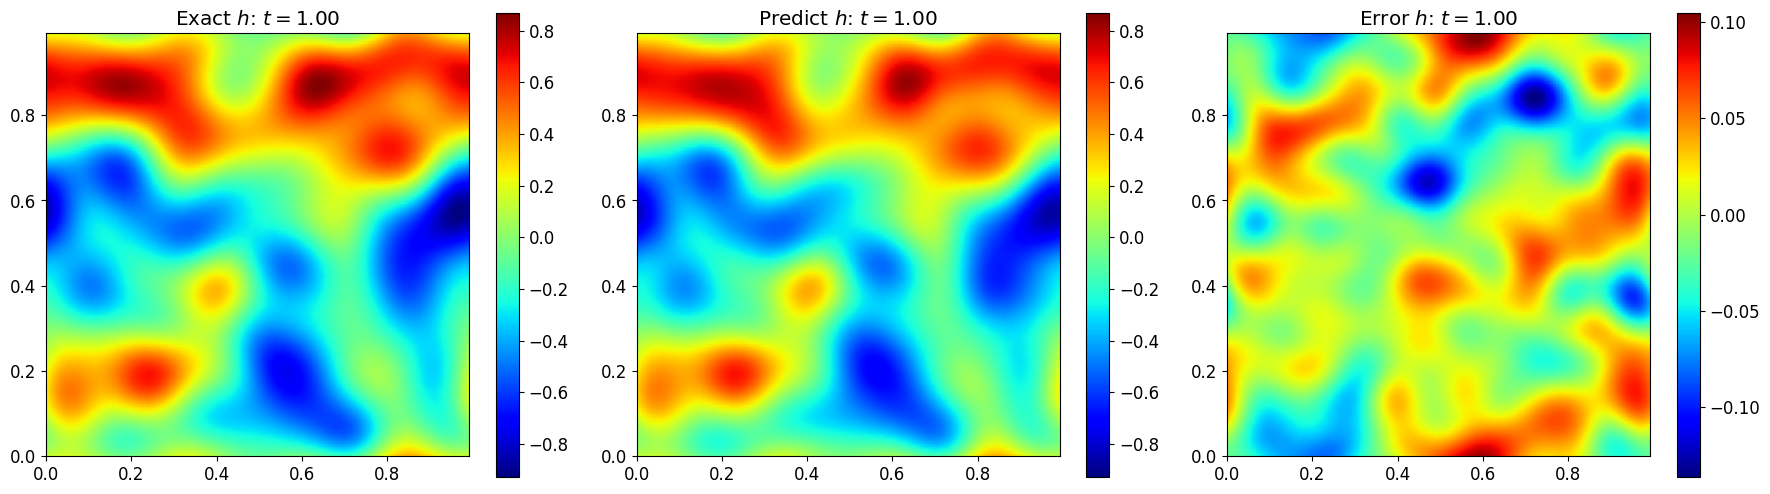

In [63]:
%matplotlib inline
movie_name = f'SWE_Linear_f{int(f)}_h.gif'
frame_basename = f'SWE_Linear_f{int(f)}_h_frame'
frame_ext = 'jpg'
plot_title = "$h$"
field = 0
val_cbar_index = -1
err_cbar_index = -1
font_size = 12
remove_frames = True

generate_movie_2D(key, test_x, test_y, preds_y, 
                  plot_title=plot_title, 
                  field=field, 
                  val_cbar_index=val_cbar_index, 
                  err_cbar_index=err_cbar_index, 
                  movie_dir=movie_dir, 
                  movie_name=movie_name, 
                  frame_basename=frame_basename, 
                  frame_ext=frame_ext, 
                  remove_frames=remove_frames, 
                  font_size=font_size)


### Movie $u$

/tmp/ipykernel_1549396/3256689165.py:95: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame)


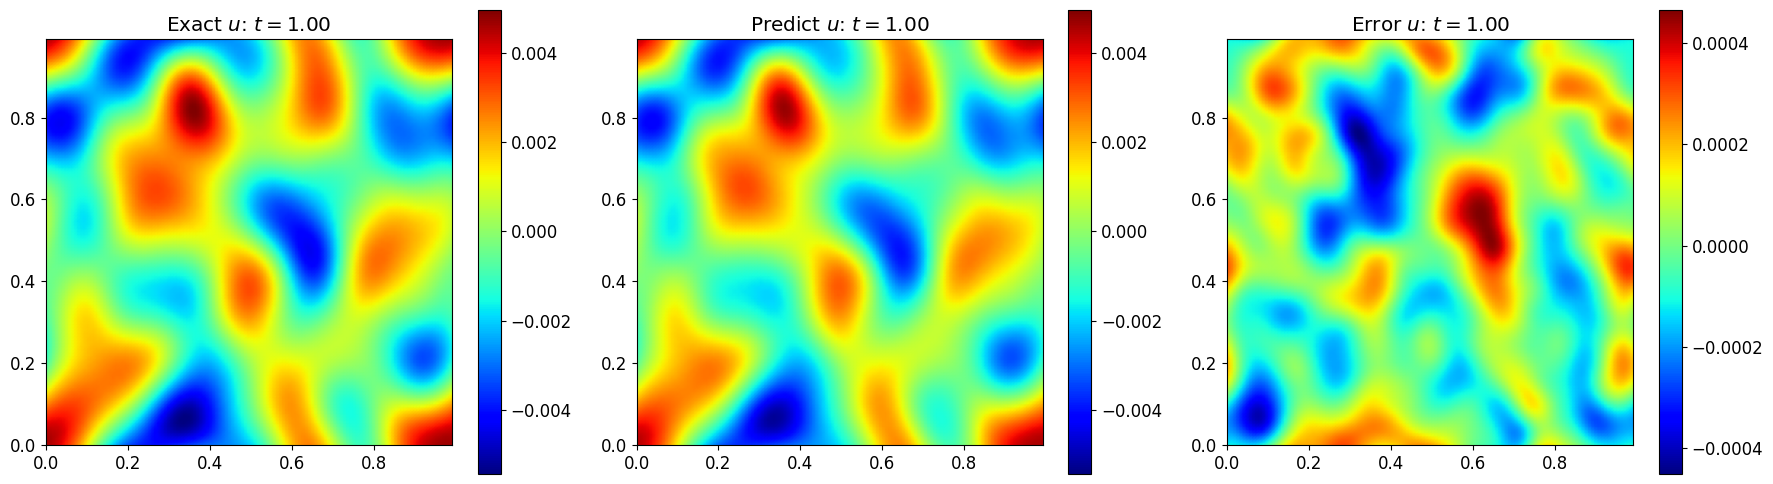

In [64]:
%matplotlib inline
movie_name = f'SWE_Linear_f{int(f)}_u.gif'
frame_basename = f'SWE_Linear_f{int(f)}_u_frame'
frame_ext = 'jpg'
plot_title = "$u$"
field = 1
val_cbar_index = -1
err_cbar_index = -1
font_size = 12
remove_frames = True

generate_movie_2D(key, test_x, test_y, preds_y, 
                  plot_title=plot_title, 
                  field=field, 
                  val_cbar_index=val_cbar_index, 
                  err_cbar_index=err_cbar_index, 
                  movie_dir=movie_dir, 
                  movie_name=movie_name, 
                  frame_basename=frame_basename, 
                  frame_ext=frame_ext, 
                  remove_frames=remove_frames, 
                  font_size=font_size)


### Movie $v$

/tmp/ipykernel_1549396/3256689165.py:95: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame)


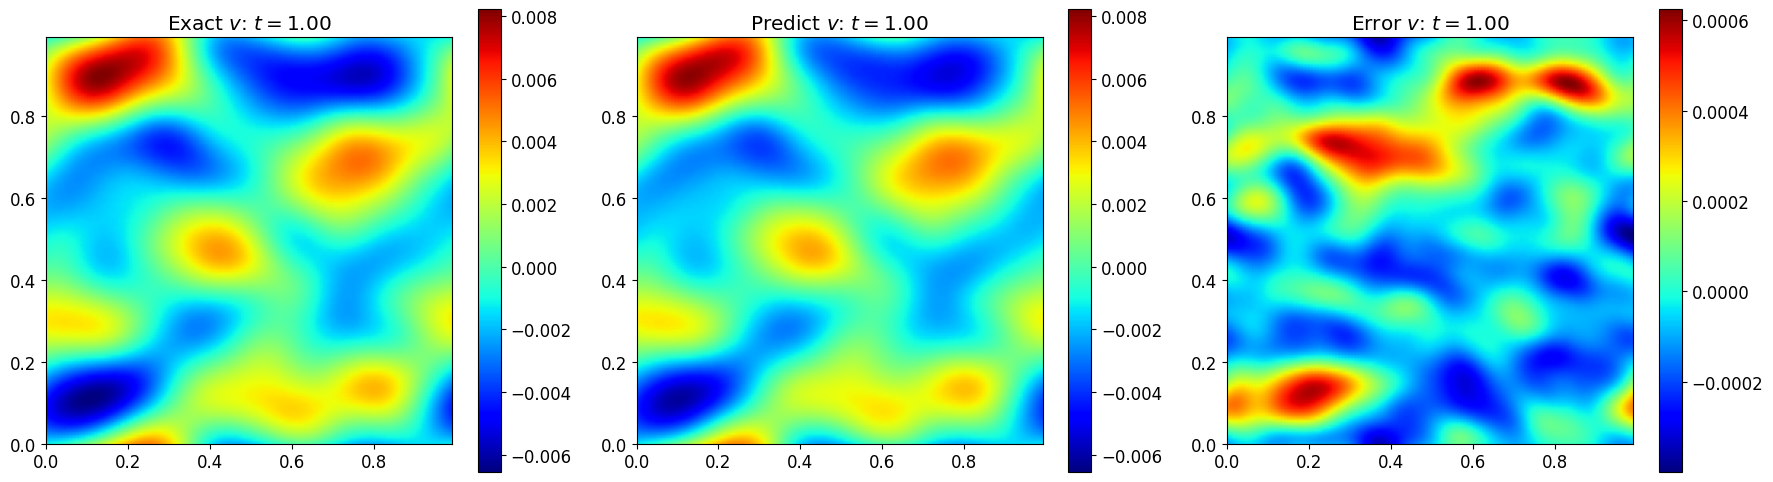

In [65]:
%matplotlib inline
movie_name = f'SWE_Linear_f{int(f)}_v.gif'
frame_basename = f'SWE_Linear_f{int(f)}_v_frame'
frame_ext = 'jpg'
plot_title = "$v$"
field = 2
val_cbar_index = -1
err_cbar_index = -1
font_size = 12
remove_frames = True

generate_movie_2D(key, test_x, test_y, preds_y, 
                  plot_title=plot_title, 
                  field=field, 
                  val_cbar_index=val_cbar_index, 
                  err_cbar_index=err_cbar_index, 
                  movie_dir=movie_dir, 
                  movie_name=movie_name, 
                  frame_basename=frame_basename, 
                  frame_ext=frame_ext, 
                  remove_frames=remove_frames, 
                  font_size=font_size)
